In [2]:
import sys
import os
import pytest

from tqdm.notebook import tqdm, trange
import jax
jax.config.update("jax_enable_x64", True)
import jax.tree as jtu
import jax.numpy as np
import jax.random as jr
from jax import Array
from jax.flatten_util import ravel_pytree
import equinox as eqx
from zodiax.diffops import hessian
from zodiax.optimisation import eigen_projection

from optax import sgd, adam
import optimistix as optx

import amigo as amg
from amigo.stats import bin_data
import dorito as drt
from dorito.model_fits import PointResolvedFit as prf
from dorito.model_fits import ResolvedOIFit
from dorito.model_fits import _OIFit
from dorito.models import ResolvedAmigoModel
from dorito.models import ResolvedDiscoModel
from dorito.bases import ImageBasis
from dorito.models import BaseModeller
from dorito.stats import disco_regularised_loss_fn


from kneed import KneeLocator

import dLux.utils as dlu

# matplotlib configs
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyBboxPatch
import ehtplot
import scienceplots
import cmasher as cmr

plt.style.use(["science", "bright", "no-latex"])
new_rcParams = {
    "svg.fonttype": "none",
    "image.cmap": "inferno",
    "font.family": "serif",
    "image.origin": "lower",
    "figure.dpi": 300,
    "font.size": 8,
    "xtick.direction": "out",
    "ytick.direction": "out",
}
plt.rcParams.update(new_rcParams)

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

from frito.autoencoder.ae_utils import load_classes_from_file as lcf, run_svd
from frito import (
    TransformedResolvedDiscoModel as TRDM,
    AutoencoderBasis,
    TransformedResolvedOIFit as TROIF,
    PointResolvedOIFit as PROIF,
    PointResolvedDiscoModel as PRDM,
)
from frito.jax_gaussian import gaussian_filter
from frito.plot import main_mosaic
from frito import (
    TransformedResolvedDiscoModel as TRDM,
    AutoencoderBasis,
    TransformedResolvedOIFit as TROIF,
    PointResolvedOIFit as PROIF,
    PointResolvedDiscoModel as PRDM,
    disco_regularised_loss_forecast_fn as drl_forecast_fn,
    oi_log_likelihood_forecast as oi_ll_forecast,
    latent_gaussian_prior as lgp,
)

from frito.simulate import inject_image

In [19]:
master_key = jr.key(42)
main_data_path = "_data"
autoencoder_data_path = os.path.join(main_data_path, "autoencoder")
main_trained_model_path = os.path.join(autoencoder_data_path, "trained_models")
main_svd_path = os.path.join(autoencoder_data_path, "svd")
training_data_path = os.path.join(autoencoder_data_path, "training_data")
emnist_path = os.path.join(training_data_path, "emnist.npz")
mnist_path = os.path.join(training_data_path, "mnist.npz")
ppd_51_path = os.path.join(training_data_path, "fake_intensity_PPDs_51x51.npz")

main_out_path = "_output"
main_model_struct_path = "src/frito/autoencoder/model_structures"

# ppd_51x51_data = np.load(ppd_51_path)
# test_51x51_data = ppd_51x51_data["x_test"].astype('float64')
emnist_data = np.load(emnist_path)
test_emnist_data = emnist_data['x_test'].astype('float64')

disco_HD100546_path = os.path.join(
    main_data_path, "jwst", "HD100546", "disco", "cal_vis_HD-100546.npy"
)
disco_HD135344B_path = os.path.join(
    main_data_path, "jwst", "HD135344B", "disco", "cal_vis_HD135344B.npy"
)
disco_PDS70_path = os.path.join(
    main_data_path, "jwst", "PDS70", "disco", "bgmask_cal_vis_pds70.npy"
)

In [4]:
disco_PDS70 = np.load(disco_PDS70_path, allow_pickle=True).item()
disco_HD100546 = np.load(disco_HD100546_path, allow_pickle=True).item()
disco_HD135344B = np.load(disco_HD135344B_path, allow_pickle=True).item()

Model: widest
Model Struct: src/frito/autoencoder/model_structures/widest_model.py
Trained Model Path: _data/autoencoder/trained_models/emnist/emnist_widest_best.eqx
Autoencoder Classes: {'autoencoder': <class 'widest_model.autoencoder'>, 'decoder': <class 'widest_model.decoder'>, 'encoder': <class 'widest_model.encoder'>}


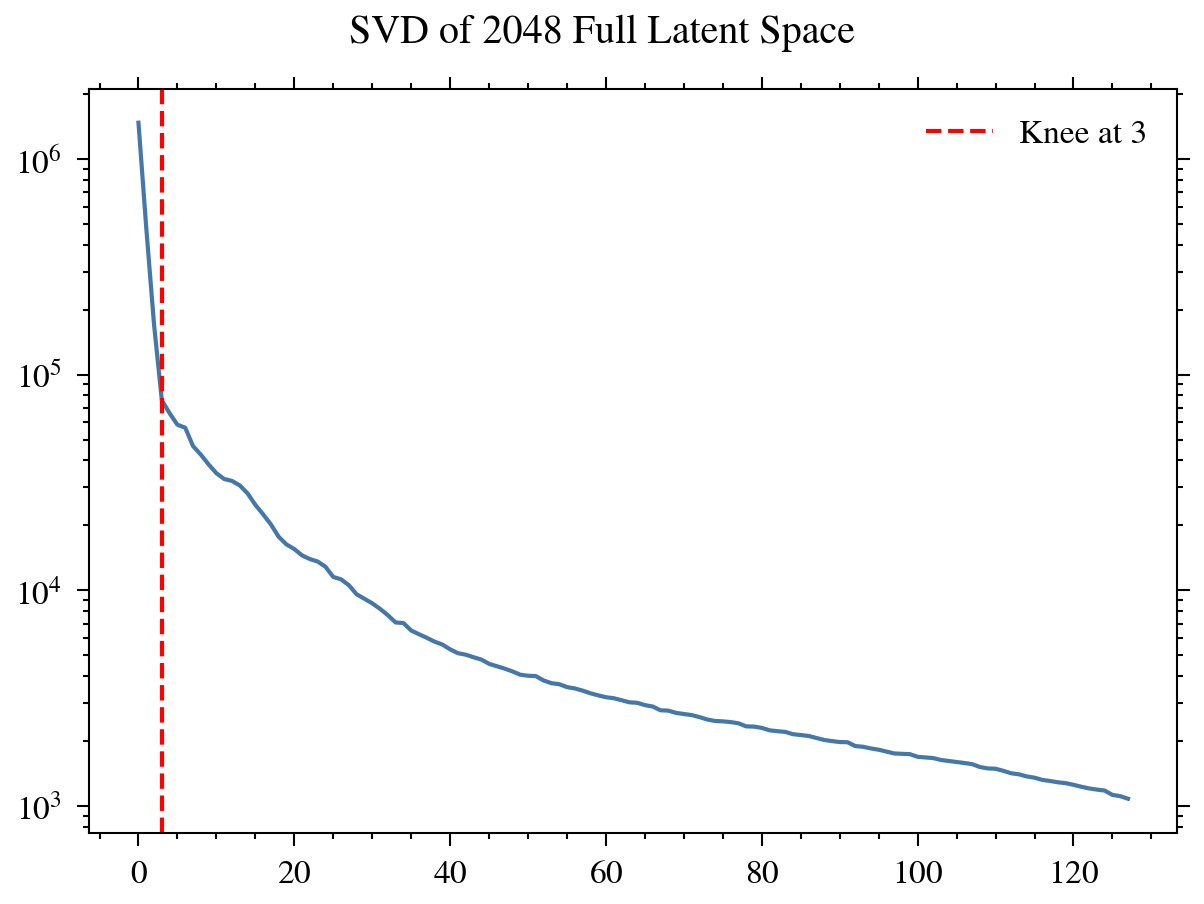

Text(0.5, 1.0, 'Initial Distribution | Sum: 1.0')

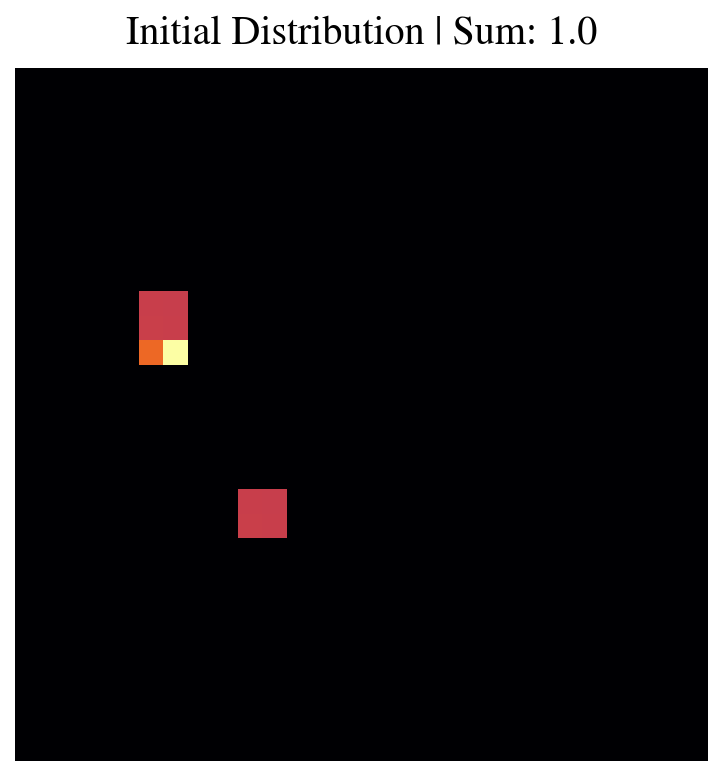

In [20]:
model_key, master_key = jr.split(master_key, 2)
model_type = "emnist"
# i = 16
# model_names = [
#     "0_0",
#     "0_2",
#     "1_0",
#     "1_2",
#     "2_0",
#     "2_1",
#     "2_2",
#     "3_0",
#     "3_1",
#     "3_2",
#     "4_0",
#     "4_1",
#     "4_2",
#     "7_0",
#     "7_1",
#     "7_2",
#     "7_4",
#     "7_5",
#     "8_0",
#     "8_2",
#     "8_3",
#     "8_4",
#     "8_5",
#     "8_6",
# ]
# model_name = model_names[i]
model_name='widest'
model_struct_path = os.path.join(
    main_model_struct_path, f"{model_name}_model.py"
)
trained_model_path = os.path.join(
    main_trained_model_path, model_type, f"{model_type}_{model_name}_best.eqx"
)
autoencoder_classes = lcf(model_struct_path)
autoencoder = autoencoder_classes["autoencoder"](key=model_key)
base_autoencoder = eqx.tree_deserialise_leaves(trained_model_path, autoencoder)

print(f"Model: {model_name}")
print(f"Model Struct: {model_struct_path}")
print(f"Trained Model Path: {trained_model_path}")
print(f"Autoencoder Classes: {autoencoder_classes}")

svd_path = "/Users/jonahgoldfine/Documents/Important Documents/packages/frito/_data/autoencoder/svd/emnist_model_widest_svd.npz"
svd = np.load(svd_path)

k1 = KneeLocator(
    np.arange(len(svd["s"])),
    svd["s"],
    curve="convex",
    direction="decreasing",
    online=True,
)

fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
fig.suptitle("SVD of 2048 Full Latent Space")
ax.plot(svd["s"], marker=",")
ax.axvline(k1.knee, color="r", linestyle="--", label=f"Knee at {k1.knee}")
ax.legend()
ax.set_yscale("log")
plt.show()

tmp_keys = jr.split(master_key, 3)
suture_keys = tmp_keys[:2]
master_key = tmp_keys[2]

# new_encode_in = base_autoencoder.modules[0].layers[-1].in_features
# new_encode_out = int(k1.knee)
# new_encode_latent_weights = (
#     base_autoencoder.modules[0].layers[-1].weight[:new_encode_out, :]
# )
# new_encode_latent_biases = (
#     base_autoencoder.modules[0].layers[-1].bias[:new_encode_out]
# )
# new_encode_linear = eqx.nn.Linear(
#     in_features=new_encode_in, out_features=new_encode_out, key=suture_keys[0]
# )
# trained_new_encode_linear = eqx.tree_at(
#     lambda l: l.weight, new_encode_linear, new_encode_latent_weights
# )
# trained_new_encode_linear = eqx.tree_at(
#     lambda l: l.bias, trained_new_encode_linear, new_encode_latent_biases
# )
# sutured_ae_struct = eqx.tree_at(
#     lambda m: m.modules[0].layers[-1],
#     base_autoencoder,
#     trained_new_encode_linear,
# )


def embed(X, knee, m, s, v):
    return (X - m) @ v.T / np.sqrt(s ** 2 / 128)


embed_layer = eqx.nn.Lambda(
    lambda z: embed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers,
    base_autoencoder,
    base_autoencoder.modules[0].layers + [embed_layer],
)


def unembed(embedded, knee, m, s, v):
    return ((embedded) * np.sqrt(s ** 2 / 128)) @ v + m


unembed_layer = eqx.nn.Lambda(
    lambda z: unembed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae = eqx.tree_at(
    lambda m: m.modules[1].layers,
    sutured_ae_struct,
    [unembed_layer] + sutured_ae_struct.modules[1].layers,
)

# new_decode_out = sutured_ae_struct.modules[1].layers[2].out_features
# new_decode_in = int(k1.knee)
# new_decode_latent_weights = (
#     sutured_ae_struct.modules[1].layers[2].weight[:, :new_decode_in]
# )
# new_decode_latent_biases = sutured_ae_struct.modules[1].layers[2].bias
# new_decode_linear = eqx.nn.Linear(
#     in_features=new_decode_in, out_features=new_decode_out, key=suture_keys[1]
# )
# trained_new_decode_linear = eqx.tree_at(
#     lambda l: l.weight, new_decode_linear, new_decode_latent_weights
# )
# trained_new_decode_linear = eqx.tree_at(
#     lambda l: l.bias, trained_new_decode_linear, new_decode_latent_biases
# )
# sutured_ae_struct = eqx.tree_at(
#     lambda m: m.modules[1].layers[2],
#     sutured_ae_struct,
#     trained_new_decode_linear,
# )

# sutured_model_path = os.path.join(
#     main_trained_model_path, model_type, f"{model_name}_Rbest.eqx"
# )
# # sutured_ae = eqx.tree_deserialise_leaves(sutured_model_path, sutured_ae_struct)
# print(f"Suture Model Path: {sutured_model_path}")


def sum2unity(X):
    pix_sum = np.sum(X, axis=(1, 2), keepdims=True)
    norm_pix = X / pix_sum
    return norm_pix


sum2unity_layer = eqx.nn.Lambda(lambda z: sum2unity(z))
norm_sutured_ae = eqx.tree_at(
    lambda m: m.modules[1].layers,
    sutured_ae,
    sutured_ae.modules[1].layers + [sum2unity_layer],
)

# encoder, decoder = sutured_ae.modules
encoder, decoder = norm_sutured_ae.modules

# svd2_path = os.path.join(
#     main_svd_path, f"{model_type}_retrain_model_{model_name}_svd.npz"
# )
# svd2 = np.load(svd2_path)
# k2 = KneeLocator(
#     np.arange(len(svd2["s"])),
#     svd2["s"],
#     curve="convex",
#     direction="decreasing",
#     online=True,
# )

# fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
# fig.suptitle("SVD of retrained latent space")
# ax.plot(svd2["s"], marker=",")
# ax.axvline(k2.knee, color="r", linestyle="--", label=f"Knee at {k2.knee}")
# ax.legend()
# ax.set_yscale("log")
# plt.show()

# print(f"SVD Path: {svd2_path}")
# print(f"Knee at {k2.knee}")

# def embed2(X, m, s, v):
#     return (X - m) @ v.T / np.sqrt(s**2 / 99999)


# embed_layer2 = eqx.nn.Lambda(
#     lambda z: embed2(z, svd2["mean"], svd2["s"], svd2["v"])
# )
# norm2_sutured_ae = eqx.tree_at(
#     lambda m: m.modules[0].layers,
#     norm_sutured_ae,
#     norm_sutured_ae.modules[0].layers + [embed_layer2],
# )


# def unembed2(embedded, m, s, v):
#     return ((embedded) * np.sqrt(s**2 / 99999)) @ v + m


# unembed_layer2 = eqx.nn.Lambda(
#     lambda z: unembed2(z, svd2["mean"], svd2["s"], svd2["v"])
# )
# norm2_sutured_ae = eqx.tree_at(
#     lambda m: m.modules[1].layers,
#     norm2_sutured_ae,
#     [unembed_layer2] + norm2_sutured_ae.modules[1].layers,  # [1:],
# )
# encoder, decoder = norm2_sutured_ae.modules

init_latent = np.zeros((128,))
init_dist = decoder(init_latent)
init_dist = init_dist[0]
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(init_dist)
ax.set_axis_off()
ax.set_title(f"Initial Distribution | Sum: {np.sum(init_dist)}")

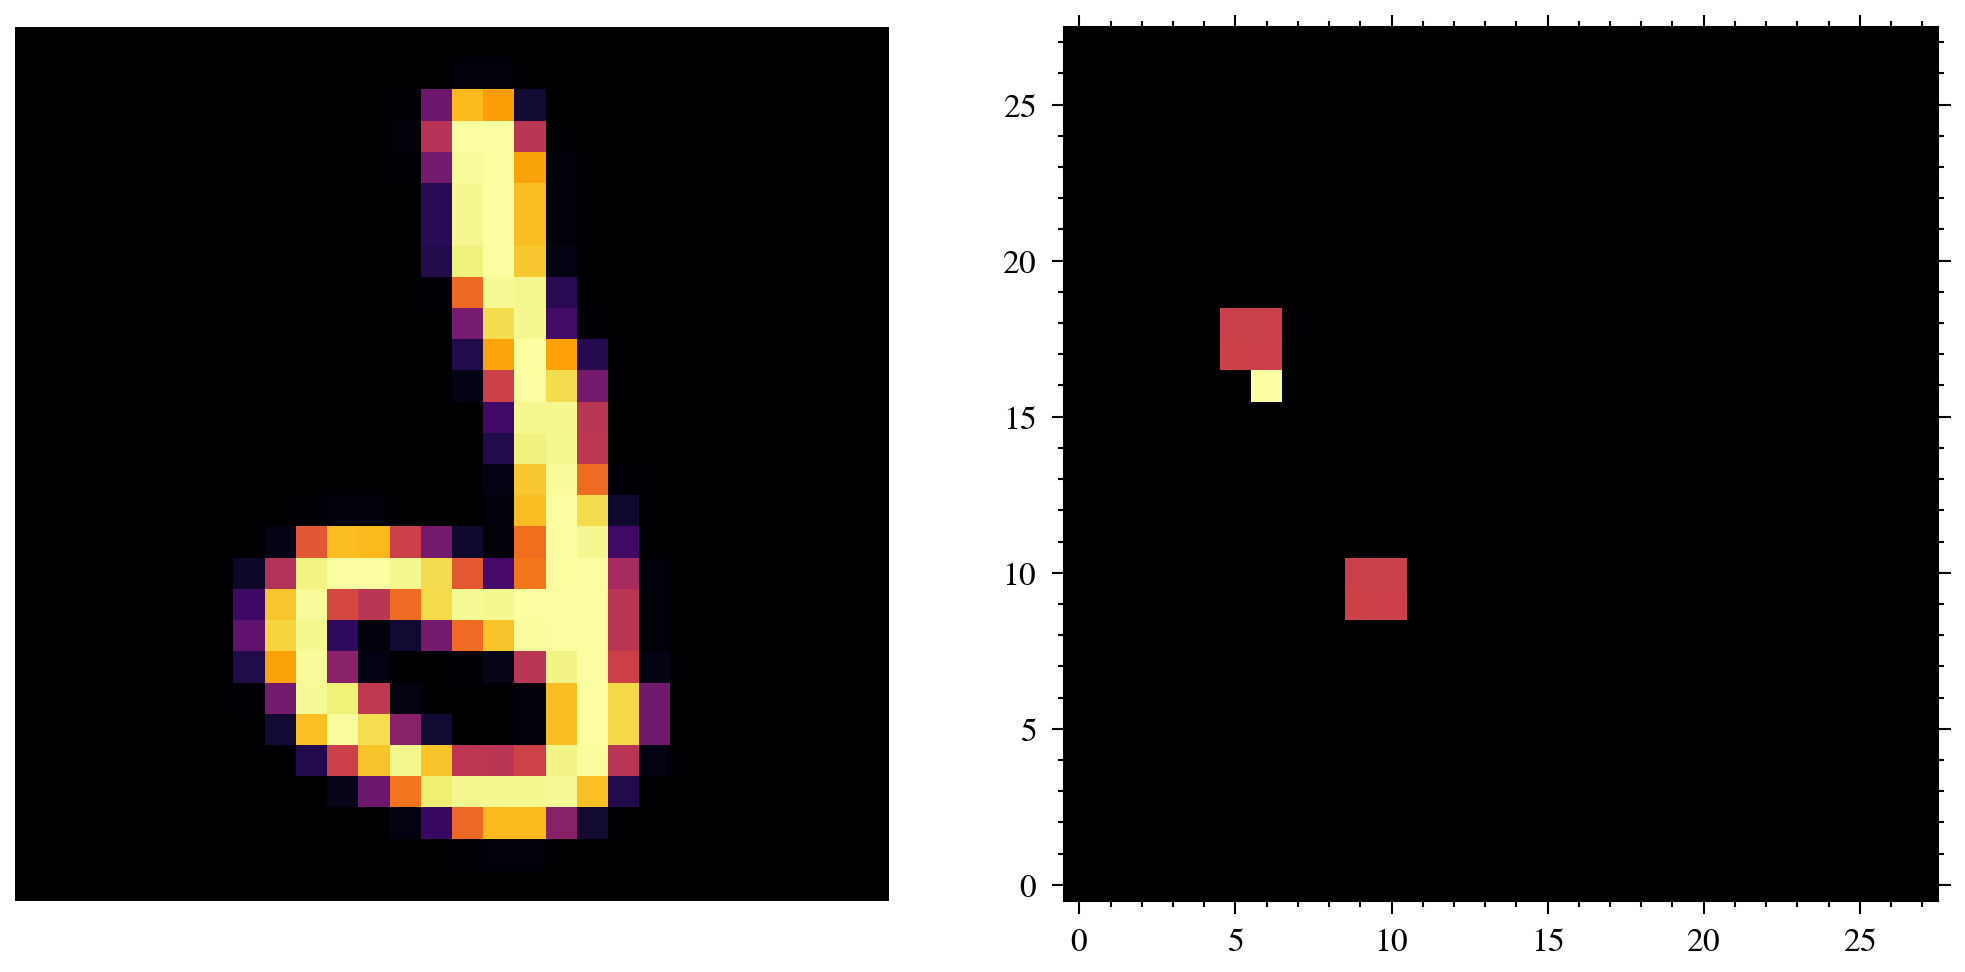

In [28]:
# PPD_idx = next(idxs)
# print(PPD_idx)
# ppd_image = test_51x51_data[PPD_idx]
emnist_image = test_emnist_data[0].T

fig, axes = plt.subplots(1,2, figsize=(8.27, 8.27/2))
axes[0].imshow(emnist_image)
axes[0].set_axis_off()
axes[1].imshow(decoder(encoder(emnist_image.reshape(1,28,28)))[0])